#TRABAJO FINAL - APRENDIZAJE DE MAQUINA I


# Predicción de Precios de Vehículos Usados
## Análisis Predictivo del Mercado Automotor de India

### Equipo de Trabajo

- **Federico Martin Zoya** (a1828)
- **Nicolas Pinzon Aparicio** (a1820)
- **Daniel Fernando Peña Pinzon** (a1818)
- **Cesar Raúl Alan Cruz Gutierrez** (2544003)

### Fuente de Datos

El presente trabajo utiliza datos del mercado automotor de India, disponibles públicamente en Kaggle: [Vehicle Dataset from CarDekho](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho/data). La plataforma CarDekho es uno de los principales portales de venta de vehículos en India, lo que proporciona una muestra representativa del mercado automotor en ese país.

### Descripción del Problema

El mercado de vehículos usados presenta un desafío significativo tanto para vendedores como compradores: la determinación del precio justo de un vehículo. Esta valoración se complica por múltiples factores:

- La depreciación no es lineal y varía según múltiples características
- El valor percibido difiere según la región y el momento de venta
- Las características técnicas tienen diferentes impactos en el valor final
- El estado de conservación y el historial del vehículo afectan su valor de mercado

### Objetivos del Análisis

#### Objetivo Principal

Desarrollar un modelo predictivo que permita estimar el precio de venta de un vehículo usado en base a sus características técnicas y de mercado, proporcionando una herramienta objetiva para la toma de decisiones en transacciones de compra-venta.

#### Objetivos Específicos

- Identificar los factores más influyentes en la determinación del precio de un vehículo usado
- Cuantificar el impacto de diferentes características en el valor final
- Segmentar el mercado para entender patrones de precio por categoría
- Desarrollar un modelo interpretable que pueda explicar sus predicciones
- Proporcionar insights útiles para vendedores y compradores

### Hipótesis Iniciales

- **Depreciación por Antigüedad:** Esperamos observar una relación inversa entre la edad del vehículo y su precio, aunque no necesariamente lineal.
- **Impacto del Kilometraje:** El kilometraje debería tener una correlación negativa con el precio, con posible efecto plateau después de cierto umbral.
- **Valor de Marca:** Ciertas marcas deberían mantener mejor su valor en el tiempo, especialmente las consideradas premium en el mercado indio.

### Relevancia del Estudio

Este análisis no solo tiene valor académico en la aplicación de técnicas de machine learning, sino que también proporciona valor práctico para:

- **Compradores:** Herramienta de validación de precios de mercado
- **Vendedores:** Optimización de estrategias de precio
- **Concesionarios:** Gestión de inventario y política de precios
- **Aseguradoras:** Valoración de vehículos para pólizas
- **Entidades Financieras:** Evaluación de riesgo en préstamos automotores

### Enfoque Metodológico

Se adoptará un enfoque integral que combine:

- Análisis exploratorio detallado
- Feature engineering basado en conocimiento del dominio
- Experimentación con múltiples modelos de machine learning
- Validación rigurosa considerando la naturaleza temporal de los datos
- Interpretación de resultados orientada al negocio


##1. Exploración y Análisis de Datos

###1.1. Imports y carga de Datasets

In [233]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import make_scorer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats

In [234]:
sns.set_style("darkgrid")
sns.set_palette("pastel")
pd.set_option('display.max_columns', None)

In [235]:
#Carga de datos
def load_datasets():
    datasets = {
        'car_data': pd.read_csv('car data.csv'),
        'car_details': pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv'),
        'car_details_v3': pd.read_csv('Car details v3.csv'),
        'car_details_v4': pd.read_csv('car details v4.csv')
    }
    return datasets

In [236]:
datasets = load_datasets()
print("Datasets cargados:")
for name, df in datasets.items():
    print(f"{name}: {df.shape} registros")

Datasets cargados:
car_data: (301, 9) registros
car_details: (4340, 8) registros
car_details_v3: (8128, 13) registros
car_details_v4: (2059, 20) registros


In [237]:
def show_samples(datasets):
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.max_rows', 20)

    print("\nMuestra de 3 registros aleatorios de cada dataset:")
    for name, df in datasets.items():
        print(f"\n{'='*100}")
        print(f"{name.upper()}")
        print(f"{'='*100}")
        print(df.sample(3, random_state=42).to_string())
        print(f"\nDimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
        print(f"Columnas: {', '.join(df.columns)}")

show_samples(datasets)


Muestra de 3 registros aleatorios de cada dataset:

CAR_DATA
             Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type Seller_Type Transmission  Owner
177  Honda Activa 125  2016           0.35           0.57       24000    Petrol  Individual    Automatic      0
289              city  2016          10.11          13.60       10980    Petrol      Dealer       Manual      0
228             verna  2012           4.95           9.40       60000    Diesel      Dealer       Manual      0

Dimensiones del dataset: 301 filas x 9 columnas
Columnas: Car_Name, Year, Selling_Price, Present_Price, Kms_Driven, Fuel_Type, Seller_Type, Transmission, Owner

CAR_DETAILS
                                 name  year  selling_price  km_driven    fuel seller_type transmission         owner
3978  Tata Manza Aqua Quadrajet BS IV  2010         165000      80000  Diesel  Individual       Manual   First Owner
1448            Renault KWID RXT BSIV  2019         250000      27000  Petrol  Ind

###1.2. Muestra y Análisis Inicial

In [238]:
# Análisis inicial

def initial_analysis(df):
    analysis = {
        'shape': df.shape,
        'dtypes': df.dtypes,
        'null_values': df.isnull().sum(),
        'duplicates': df.duplicated().sum(),
        'description': df.describe()
    }
    return analysis

In [239]:
for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"Análisis del dataset: {name}")
    print(f"{'='*50}")

    results = initial_analysis(df)

    print("\nDimensiones del dataset:")
    print(results['shape'])

    print("\nTipos de datos:")
    print(results['dtypes'])

    print("\nValores nulos por columna:")
    print(results['null_values'])

    print("\nNúmero de registros duplicados:")
    print(results['duplicates'])

    print("\nEstadísticas descriptivas:")
    print(results['description'])


Análisis del dataset: car_data

Dimensiones del dataset:
(301, 9)

Tipos de datos:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

Valores nulos por columna:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Número de registros duplicados:
2

Estadísticas descriptivas:
              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000    

###1.3. Comparativas de los datasets


Visualizaciones Comparativas de Datasets:


<Figure size 1200x600 with 0 Axes>

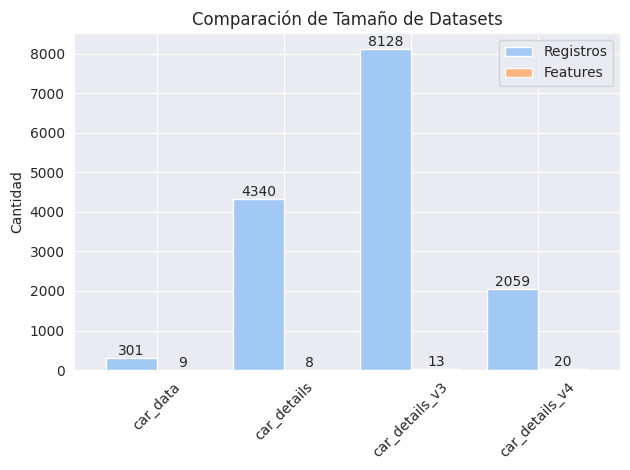

<Figure size 1200x600 with 0 Axes>

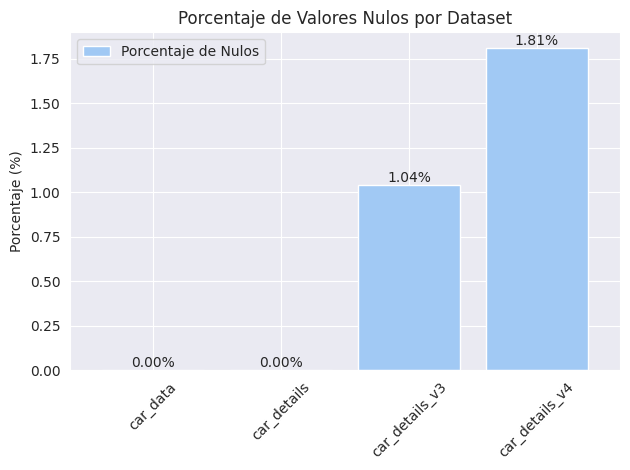

<Figure size 1200x600 with 0 Axes>

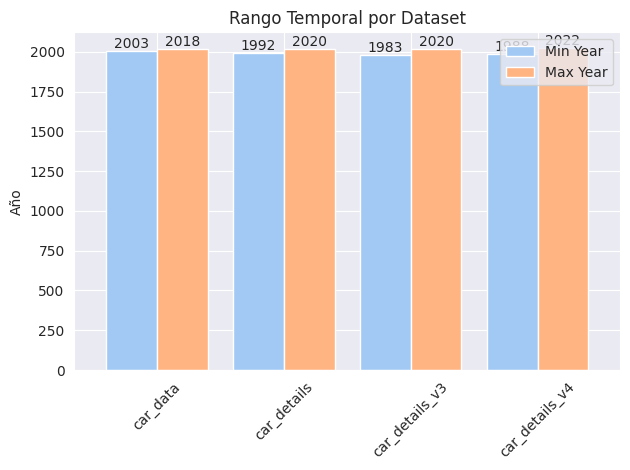

In [240]:
# Comparativas de los datasets
def plot_dataset_comparisons(datasets):
    # 1. Comparación de tamaño de datasets
    plt.figure(figsize=(12, 6))
    sizes = pd.DataFrame({
        'Registros': [df.shape[0] for df in datasets.values()],
        'Features': [df.shape[1] for df in datasets.values()]
    }, index=datasets.keys())

    ax = sizes.plot(kind='bar', width=0.8)
    plt.title('Comparación de Tamaño de Datasets')
    plt.ylabel('Cantidad')
    plt.xticks(rotation=45)
    for container in ax.containers:
        ax.bar_label(container)
    plt.tight_layout()
    plt.show()

    # 2. Comparación de valores nulos
    plt.figure(figsize=(12, 6))
    null_percentages = pd.DataFrame({
        'Porcentaje de Nulos': [df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100
                               for df in datasets.values()]
    }, index=datasets.keys())

    ax = null_percentages.plot(kind='bar', width=0.8)
    plt.title('Porcentaje de Valores Nulos por Dataset')
    plt.ylabel('Porcentaje (%)')
    plt.xticks(rotation=45)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%')
    plt.tight_layout()
    plt.show()

    # 3. Rango temporal de cada dataset
    plt.figure(figsize=(12, 6))
    year_ranges = pd.DataFrame([
        {
            'Min Year': df['year'].min() if 'year' in df.columns else df['Year'].min(),
            'Max Year': df['year'].max() if 'year' in df.columns else df['Year'].max()
        }
        for df in datasets.values()
    ], index=datasets.keys())

    ax = year_ranges.plot(kind='bar', width=0.8)
    plt.title('Rango Temporal por Dataset')
    plt.ylabel('Año')
    plt.xticks(rotation=45)
    for container in ax.containers:
        ax.bar_label(container)
    plt.tight_layout()
    plt.show()

print("\nVisualizaciones Comparativas de Datasets:")
plot_dataset_comparisons(datasets)

###1.4 Selección del Dataset Principal

Después de analizar los cuatro datasets disponibles, se selecciona `car_details_v3` como el dataset principal por las siguientes razones:

1. **Cantidad de Observaciones:**
   - Contiene 8,128 registros, la mayor cantidad entre todos los datasets.
   - Proporciona una muestra más representativa del mercado.

2. **Balance de Características:**
   - 13 features relevantes incluyendo datos técnicos importantes.
   - Incluye variables clave como `mileage`, `engine`, `max_power`, `torque` y `seats`.

3. **Calidad de Datos:**
   - Valores nulos manejables (~220 registros, <3% del total).
   - 1,202 duplicados que pueden ser tratados.

4. **Rango Temporal:**
   - Cubre desde 1983 hasta 2020.
   - Buen balance entre datos históricos y recientes.

#### Evaluación de Combinación de Datasets

Se evaluó la posibilidad de combinar `car_details_v3` y `car_details_v4`, pero se decidió no hacerlo por las siguientes razones:

1. **Incompatibilidad Estructural:**
   - Diferencias en la nomenclatura de columnas comunes.
   - Distintas unidades y formatos en variables técnicas.
   - Variaciones en la categorización de variables cualitativas.

2. **Riesgo de Sesgo:**
   - `car_details_v4` tiene un enfoque en vehículos más recientes (2016-2022).
   - Los precios en v4 son significativamente más altos.
   - Diferentes criterios de recolección de datos.

3. **Complejidad en la Integración:**
   - Potencial pérdida de información en el proceso de homogeneización.
   - Riesgo de introducir errores en la normalización de datos.
   - Dificultad para validar la consistencia de los datos combinados.

4. **Beneficio vs Costo:**
   - El beneficio de agregar más características no justifica el riesgo de introducir ruido.
   - La cantidad de registros en v3 es suficiente para un modelo robusto.
   - Las variables adicionales de v4 podrían no ser críticas para la predicción.

5. **Diferencias en el Mercado:**
   - v4 parece enfocarse en segmentos diferentes del mercado.
   - Los rangos de precios sugieren diferentes poblaciones objetivo.
   - Posibles cambios en las preferencias del mercado entre periodos.

Por estas razones, se decide proceder con `car_details_v3`, que proporciona un conjunto de datos más homogéneo y representativo para nuestro objetivo de predicción de precios.


##2. Limpieza de Datos

###2.1. EDA inical

In [241]:
# Daataframe seleccionado
df_main = datasets['car_details_v3'].copy()

# EDA INICIAL BÁSICO
def initial_eda(df):
    print("1. ANÁLISIS EXPLORATORIO INICIAL")
    print("\nA. Información básica del dataset:")
    print(f"- Dimensiones: {df.shape}")
    print(f"- Columnas: {', '.join(df.columns)}")

    print("\nB. Tipos de datos:")
    print(df.dtypes)

    print("\nC. Valores nulos por columna:")
    nulls = df.isnull().sum()
    print(nulls[nulls > 0])

    print("\nD. Duplicados:")
    print(f"Registros duplicados: {df.duplicated().sum()}")

    print("\nE. Muestra de datos:")
    print(df.head(3))

    # Visualización rápida de variables numéricas
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    plt.figure(figsize=(12, 6))
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(2, len(numeric_cols)//2 + 1, i)
        df[col].hist()
        plt.title(f'Histograma de {col}')
    plt.tight_layout()
    plt.show()

1. ANÁLISIS EXPLORATORIO INICIAL

A. Información básica del dataset:
- Dimensiones: (8128, 13)
- Columnas: name, year, selling_price, km_driven, fuel, seller_type, transmission, owner, mileage, engine, max_power, torque, seats

B. Tipos de datos:
name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object

C. Valores nulos por columna:
mileage      221
engine       221
max_power    215
torque       222
seats        221
dtype: int64

D. Duplicados:
Registros duplicados: 1202

E. Muestra de datos:
                           name  year  selling_price  km_driven    fuel seller_type transmission         owner     mileage   engine   max_power                 torque  seats
0        Maruti Swift Dzire VDI  2014         

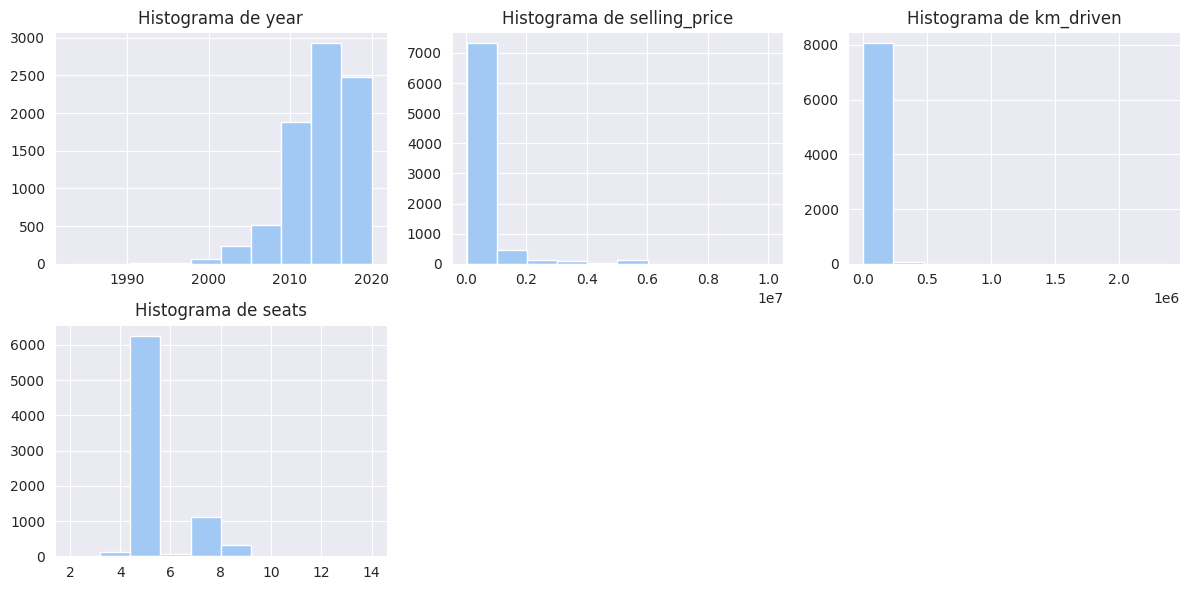

In [242]:
initial_eda(df_main)

###2.3. Limpieza Básica

In [243]:
# LIMPIEZA BÁSICA
def basic_cleaning(df):
    print("\n2. LIMPIEZA BÁSICA DE DATOS")
    df_clean = df.copy()

    duplicados_iniciales = df_clean.duplicated().sum()
    df_clean.drop_duplicates(inplace=True)
    print(f"\nA. Duplicados eliminados: {duplicados_iniciales}")

    # Separar 'name' en 'brand' y 'model'
    df_clean['brand'] = df_clean['name'].str.split().str[0]  # Primera palabra como brand
    df_clean['model'] = df_clean['name'].str.split(n=1).str[1]  # Resto como model
    print("\nB. Columna 'name' separada en 'brand' y 'model'.")

    df_clean['engine_cc'] = df_clean['engine'].str.extract('(\d+)').astype(float)

    df_clean['max_power_bhp'] = df_clean['max_power'].str.extract('(\d+\.?\d*)').astype(float)
    df_clean['max_power_bhp'] = df_clean['max_power_bhp'].replace(0, np.nan)

    def standardize_mileage(x):
        if pd.isna(x):
            return np.nan
        if 'km/kg' in str(x):
            value = float(str(x).split()[0])
            return value * 1.39
        return float(str(x).split()[0])

    df_clean['mileage_kmpl'] = df_clean['mileage'].apply(standardize_mileage)

    def extract_torque_values(x):
        if pd.isna(x):
            return np.nan, np.nan

        patterns = {
            'nm_standard': r'(\d+\.?\d*)\s*Nm',
            'nm_at': r'(\d+\.?\d*)\s*Nm\s*@',
            'kgm_standard': r'(\d+\.?\d*)\s*kgm',
            'kgm_at': r'(\d+\.?\d*)\s*kgm\s*@',
            'nm_parenthesis': r'\((\d+\.?\d*)\s*Nm\)',
            'kgm_parenthesis': r'\((\d+\.?\d*)\s*kgm\)',
            'bare_number_at': r'^(\d+\.?\d*)\s*@',
            'number_with_at': r'(\d+\.?\d*)\s*@',
            'kgm_at_rpm': r'(\d+\.?\d*)\s*\(kgm@\s*rpm\)',
            'nm_range': r'(\d+\.?\d*)-(\d+\.?\d*)\s*Nm',
            'kgm_range': r'(\d+\.?\d*)-(\d+\.?\d*)\s*kgm',
        }

        rpm_patterns = {
            'standard': r'@\s*(\d+)(?:\s*rpm)?',
            'range': r'@\s*(\d+)-(\d+)(?:\s*rpm)?',
            'parenthesis': r'\((\d+)\s*rpm\)',
            'range_parenthesis': r'\((\d+)-(\d+)\s*rpm\)',
            'at_rpm': r'@\s*(\d+)\s*\(rpm\)',
        }

        torque_value = np.nan
        rpm_value = np.nan
        x_lower = str(x).lower().strip()

        for pattern_name, pattern in patterns.items():
            match = re.search(pattern, x_lower, re.IGNORECASE)
            if match:
                if 'range' in pattern_name:
                    torque_value = float(match.group(2))
                else:
                    torque_value = float(match.group(1))
                if 'kgm' in pattern_name:
                    torque_value *= 9.80665
                break

        for pattern_name, pattern in rpm_patterns.items():
            match = re.search(pattern, x_lower, re.IGNORECASE)
            if match:
                if 'range' in pattern_name:
                    min_rpm = float(match.group(1))
                    max_rpm = float(match.group(2))
                    rpm_value = (min_rpm + max_rpm) / 2
                else:
                    rpm_value = float(match.group(1))
                break

        return torque_value, rpm_value

    # Extracción de torque
    df_clean[['torque_nm', 'torque_rpm']] = pd.DataFrame(
        df_clean['torque'].apply(extract_torque_values).tolist(),
        index=df_clean.index
    )

    print("\nB. Conversiones realizadas: engine_cc, max_power_bhp, mileage_kmpl, torque_nm, torque_rpm")

    owner_map = {
        'First Owner': 1,
        'Second Owner': 2,
        'Third Owner': 3,
        'Fourth & Above Owner': 4,
        'Test Drive Car': 5
    }
    df_clean['owner_rank'] = df_clean['owner'].map(owner_map)
    print("\nC. Owner convertido a ranking numérico")

    # NO se imputan nulos aquí; la imputación debe hacerse posteriormente, después de separar los sets de entrenamiento y prueba
    # Comentado para evitar imputación anticipada
    # numeric_cols = ['engine_cc', 'max_power_bhp', 'mileage_kmpl', 'seats', 'torque_nm', 'torque_rpm']
    # for col in numeric_cols:
    #     df_clean[col].fillna(df_clean[col].median(), inplace=True)

    print("\nD. Valores nulos pendientes de imputación posterior")
    print("Valores nulos restantes:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

    print("\nE. Ejemplos de procesamiento de torque:")
    print(df_clean[['torque', 'torque_nm', 'torque_rpm']].sample(5, random_state=42))

    return df_clean

In [244]:
df_clean = basic_cleaning(df_main)


2. LIMPIEZA BÁSICA DE DATOS

A. Duplicados eliminados: 1202

B. Columna 'name' separada en 'brand' y 'model'.

B. Conversiones realizadas: engine_cc, max_power_bhp, mileage_kmpl, torque_nm, torque_rpm

C. Owner convertido a ranking numérico

D. Valores nulos pendientes de imputación posterior
Valores nulos restantes:
mileage          208
engine           208
max_power        205
torque           209
seats            208
engine_cc        208
max_power_bhp    209
mileage_kmpl     208
torque_nm        217
torque_rpm       433
dtype: int64

E. Ejemplos de procesamiento de torque:
                         torque  torque_nm  torque_rpm
8077  20.4@ 1400-3400(kgm@ rpm)       20.4      1400.0
4094        330Nm@ 1600-2800rpm      330.0      1600.0
6493        205Nm@ 1750-3250rpm      205.0      1750.0
4339       8.6@ 3,500(kgm@ rpm)        8.6         3.0
2535             200Nm@ 1750rpm      200.0      1750.0


##3. Análisis Exploratorio Detallado (EDA)



*   3.1 Análisis de Variables Numéricas
*   3.2 Análisis de Variables Categóricas
*   3.3 Boxplots por Categorías
*   3.4 Correlación de Variables Numéricas
*   3.5 Análisis Adicional: Categorías y Precio




###3.1. Análisis de Variables Numéricas

In [245]:
numeric_cols = ['year', 'selling_price', 'km_driven', 'engine_cc',
                    'max_power_bhp', 'mileage_kmpl', 'seats']

def detailed_eda_3_1(df):
    print("\n3. ANÁLISIS EXPLORATORIO DETALLADO")

    # ============================
    # 3.1. Análisis de variables numéricas
    # ============================

    print("\n3.1. Estadísticas descriptivas de variables numéricas:")
    print(df[numeric_cols].describe())

    # Transformación logarítmica de 'selling_price'
    if 'selling_price' in df.columns:
        df['selling_price_log'] = np.log1p(df['selling_price'])
        print("\nSe aplicó transformación logarítmica a 'selling_price'.")

    # Histograma y boxplot de variables numéricas
    print("\nVisualización de distribuciones numéricas:")
    fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, len(numeric_cols) * 3))
    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col], kde=True, ax=axes[i, 0])
        axes[i, 0].set_title(f"Distribución de {col}")

        sns.boxplot(x=df[col], ax=axes[i, 1])
        axes[i, 1].set_title(f"Boxplot de {col}")
    plt.tight_layout()
    plt.show()


3. ANÁLISIS EXPLORATORIO DETALLADO

3.1. Estadísticas descriptivas de variables numéricas:
              year  selling_price     km_driven    engine_cc  max_power_bhp  mileage_kmpl        seats
count  6926.000000   6.926000e+03  6.926000e+03  6718.000000    6717.000000   6718.000000  6718.000000
mean   2013.420300   5.172707e+05  7.399568e+04  1430.891337      87.766100     19.575467     5.434653
std       4.078286   5.197670e+05  5.835810e+04   493.493277      31.724555      4.271735     0.984230
min    1983.000000   2.999900e+04  1.000000e+00   624.000000      32.800000      0.000000     2.000000
25%    2011.000000   2.500000e+05  4.000000e+04  1197.000000      67.100000     16.800000     5.000000
50%    2014.000000   4.000000e+05  7.000000e+04  1248.000000      81.830000     19.500000     5.000000
75%    2017.000000   6.335000e+05  1.000000e+05  1498.000000     100.000000     22.540000     5.000000
max    2020.000000   1.000000e+07  2.360457e+06  3604.000000     400.000000     46.4

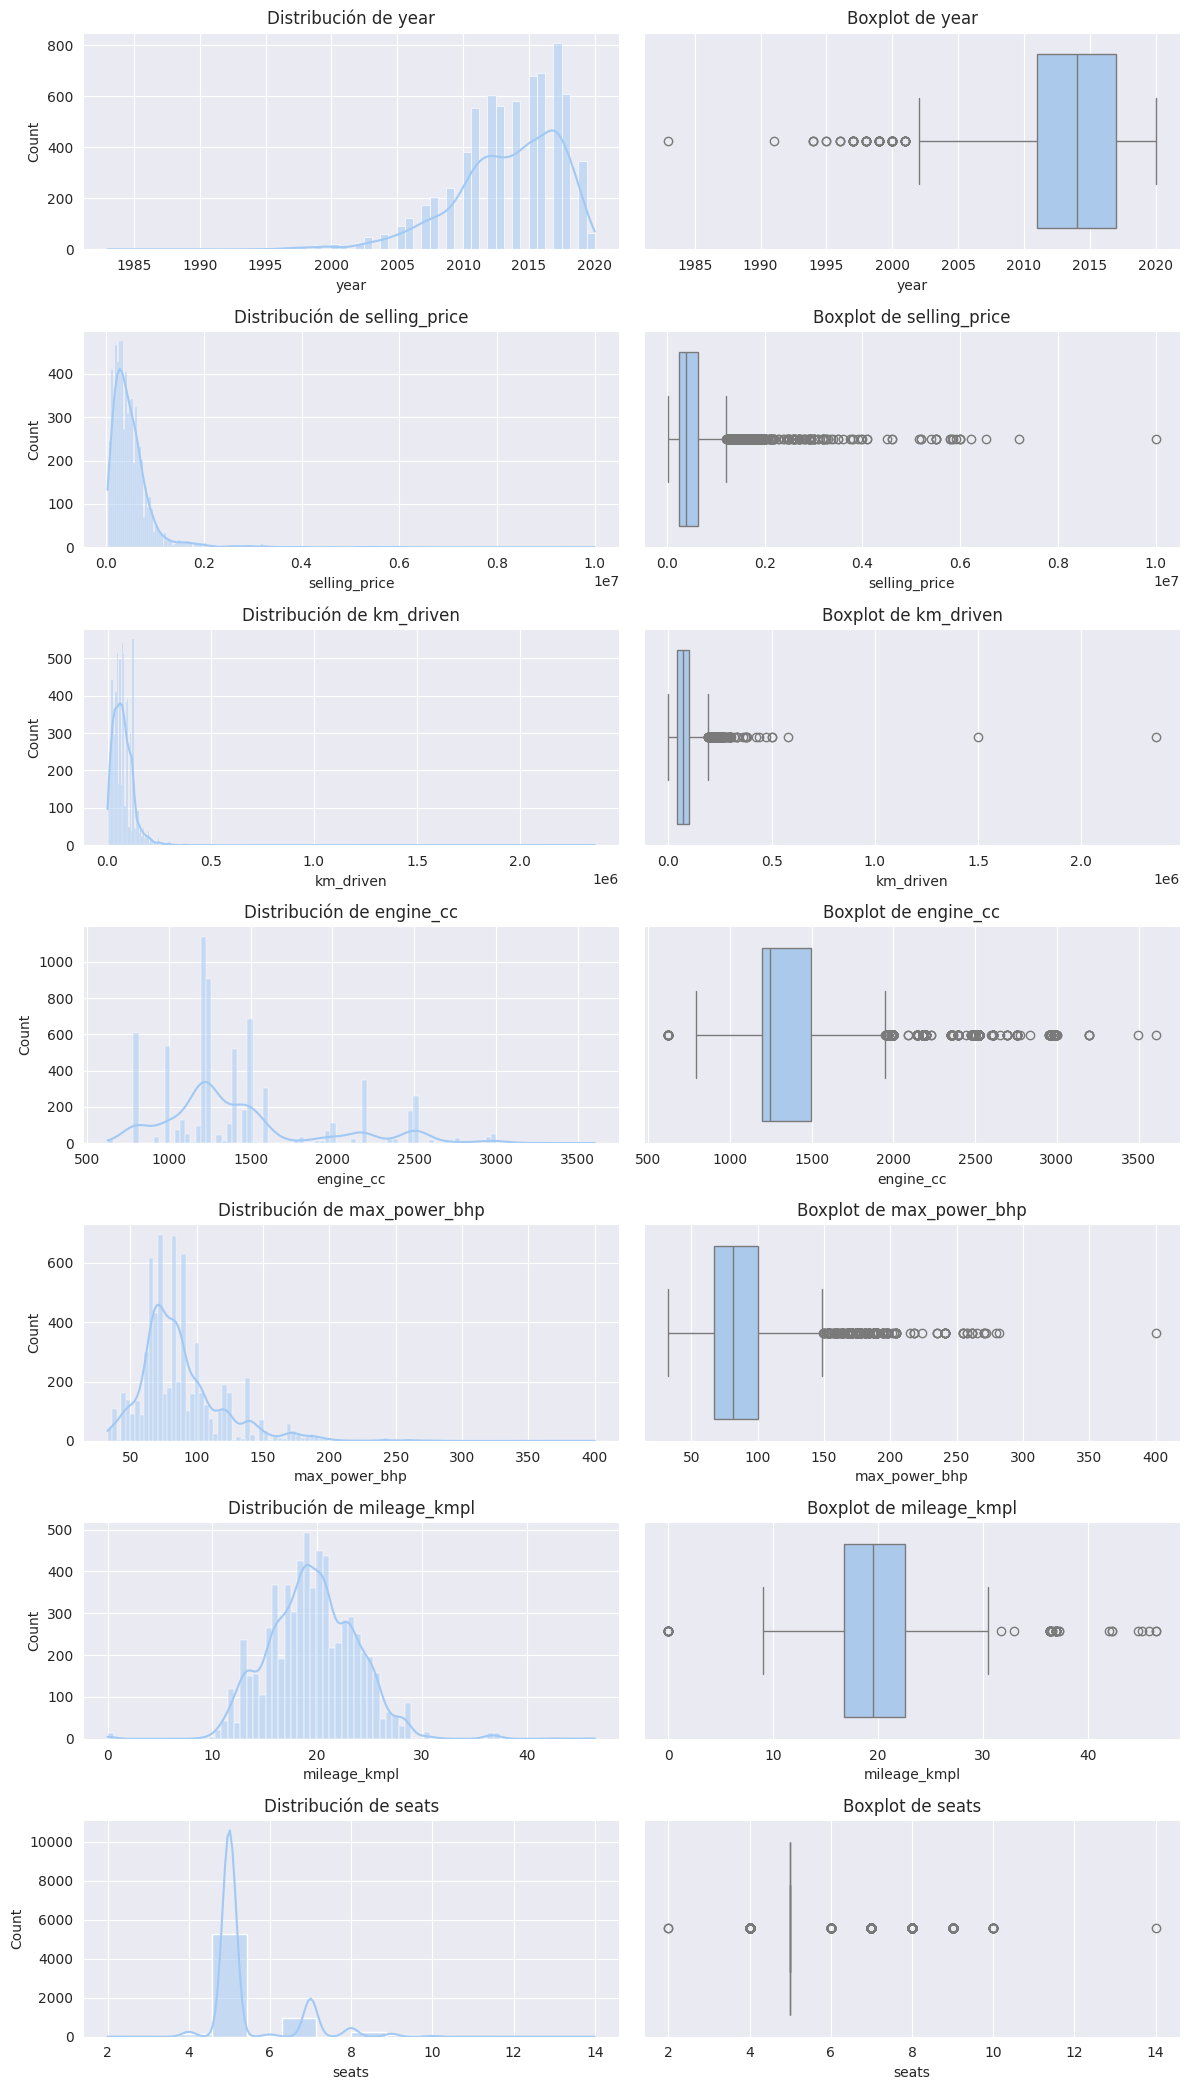

In [246]:
detailed_eda_3_1(df_clean)

###3.2. Análisis de Variables Categóricas

In [247]:
categorical_cols = ['brand', 'model', 'fuel', 'seller_type', 'transmission', 'owner']

def detailed_eda_3_2(df):
    # ============================
    # 3.2. Análisis de variables categóricas
    # ============================

    print("\n3.2. Distribución de variables categóricas:")
    for col in categorical_cols:
        print(f"\nDistribución de '{col}':")
        print(df[col].value_counts(normalize=True).multiply(100).round(2))

    # Visualización de distribuciones categóricas (Top 10 valores)
    print("\nVisualización de variables categóricas (Top 10 valores):")
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for i, col in enumerate(categorical_cols):
        top_values = df[col].value_counts().head(10).index
        sns.countplot(data=df[df[col].isin(top_values)], x=col, ax=axes[i // 3, i % 3])
        axes[i // 3, i % 3].set_title(f"Distribución de {col} (Top 10)")
        axes[i // 3, i % 3].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


3.2. Distribución de variables categóricas:

Distribución de 'brand':
brand
Maruti      31.26
Hyundai     18.29
Mahindra    10.44
Tata         9.34
Honda        5.23
            ...  
MG           0.04
Ashok        0.01
Lexus        0.01
Opel         0.01
Peugeot      0.01
Name: proportion, Length: 32, dtype: float64

Distribución de 'model':
model
Swift Dzire VDI                          1.70
Alto 800 LXI                             1.10
Alto LXi                                 1.00
Swift VDI                                0.87
Swift VDI BSIV                           0.81
                                         ... 
KUV 100 G80 K4 Plus                      0.01
Getz 1.1 GVS                             0.01
800 EX BSII                              0.01
GO T Option                              0.01
Innova 2.5 GX (Diesel) 8 Seater BS IV    0.01
Name: proportion, Length: 2058, dtype: float64

Distribución de 'fuel':
fuel
Diesel    54.22
Petrol    44.43
CNG        0.81
LPG        0.55
N

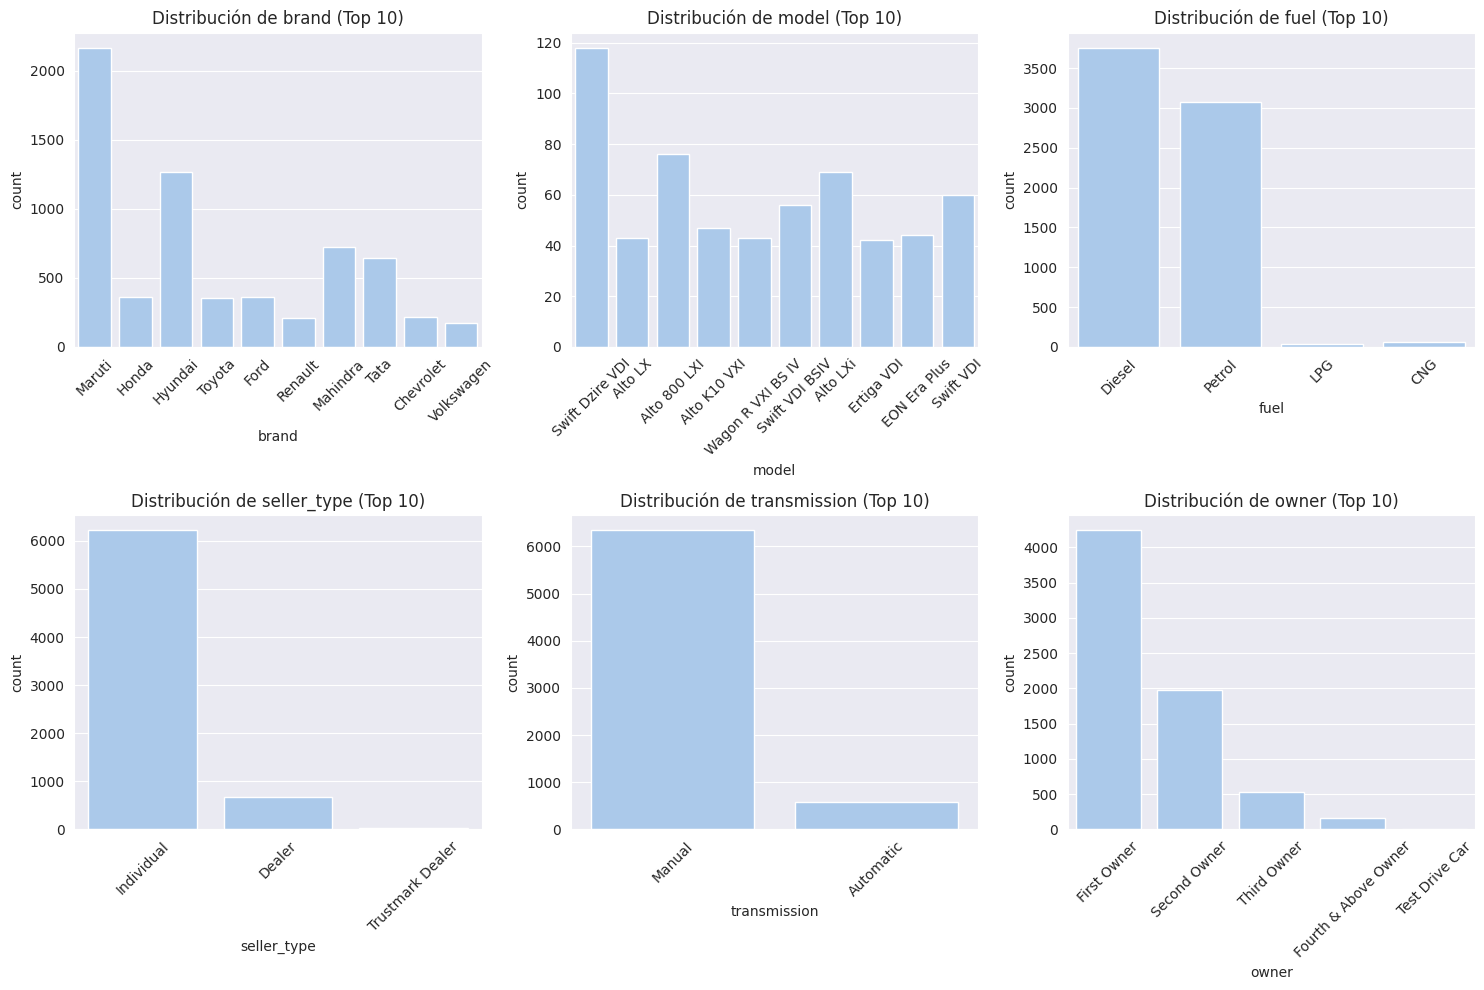

In [248]:
detailed_eda_3_2(df_clean)

###3.3 Boxplots por Categorías

In [249]:
def detailed_eda_3_3(df):
    # ============================
    # 3.3. Boxplots de 'selling_price_log' por variables categóricas
    # ============================
    print("\n3.3. Variación de 'selling_price_log' según variables categóricas:")
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for i, col in enumerate(categorical_cols):
        top_values = df[col].value_counts().head(10).index
        sns.boxplot(data=df[df[col].isin(top_values)], x=col, y='selling_price_log', ax=axes[i // 3, i % 3])
        axes[i // 3, i % 3].set_title(f"'selling_price_log' según {col} (Top 10)")
        axes[i // 3, i % 3].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


3.3. Variación de 'selling_price_log' según variables categóricas:


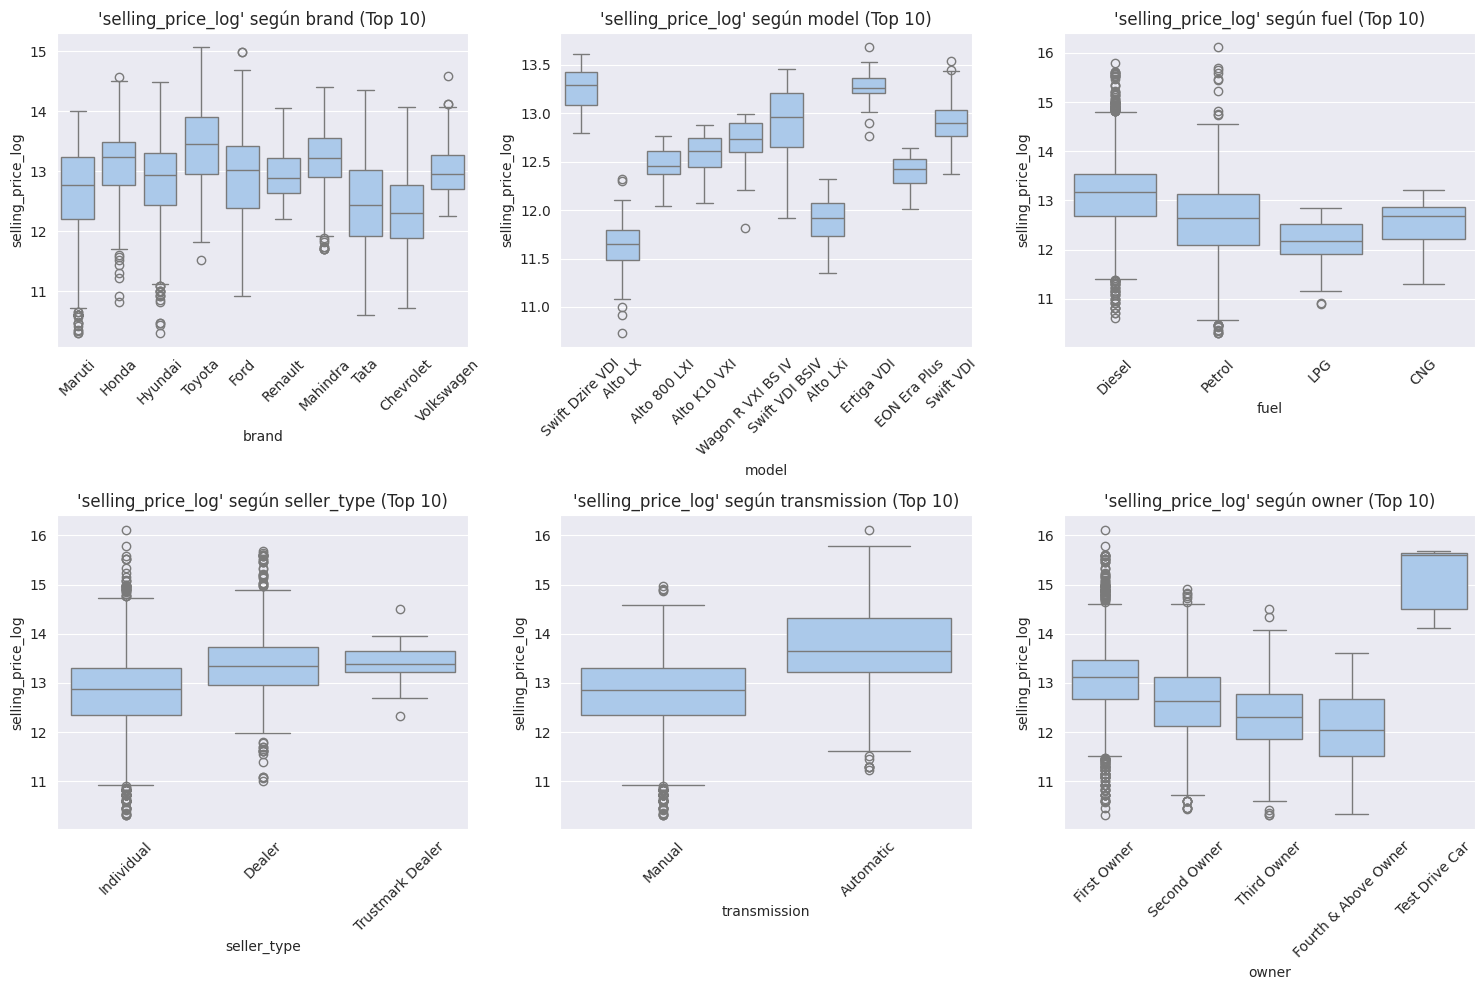

In [250]:
detailed_eda_3_3(df_clean)

###3.4 Correlación de Variables Numéricas

In [251]:
def detailed_eda_3_4(df):
    # ============================
    # 3.4. Correlación de variables numéricas
    # ============================
    print("\n3.4. Correlaciones con 'selling_price_log':")
    numeric_corr = df[numeric_cols + ['selling_price_log']].corr()['selling_price_log'].sort_values(ascending=False)
    print(numeric_corr)

    # Gráfico de barras de correlaciones
    plt.figure(figsize=(10, 5))
    sns.barplot(x=numeric_corr.index, y=numeric_corr.values, palette='coolwarm')
    plt.title("Correlación de 'selling_price_log' con variables numéricas")
    plt.ylabel("Coeficiente de correlación")
    plt.xticks(rotation=45)
    plt.show()

    # Matriz de Correlación Completa
    print("\nE. Matriz de Correlaciones:")
    ordered_cols = ['selling_price_log'] + [col for col in numeric_cols if col != 'selling_price']
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[ordered_cols].corr(), annot=True, cmap='coolwarm', center=0)
    plt.title("Matriz de Correlaciones 'selling_price_log'")
    plt.show()


3.4. Correlaciones con 'selling_price_log':
selling_price_log    1.000000
selling_price        0.782313
year                 0.718650
max_power_bhp        0.654906
engine_cc            0.473843
seats                0.267400
mileage_kmpl         0.002350
km_driven           -0.188237
Name: selling_price_log, dtype: float64


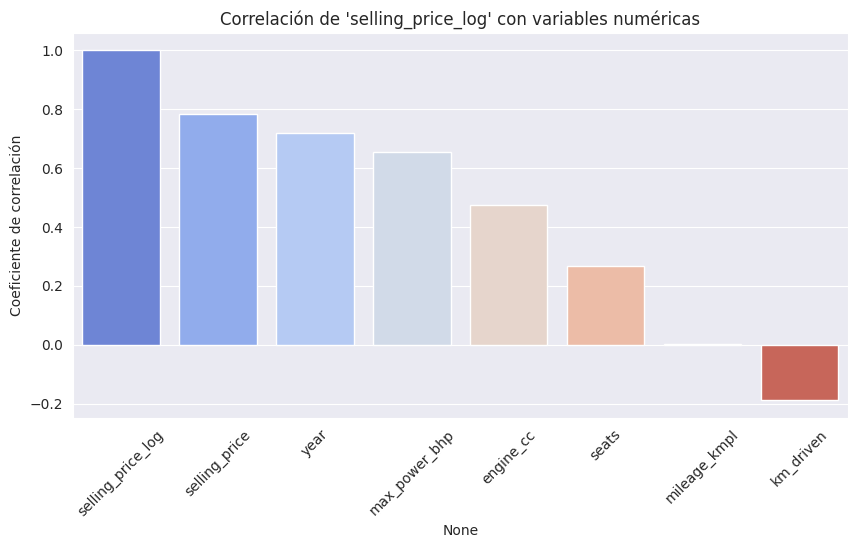


E. Matriz de Correlaciones:


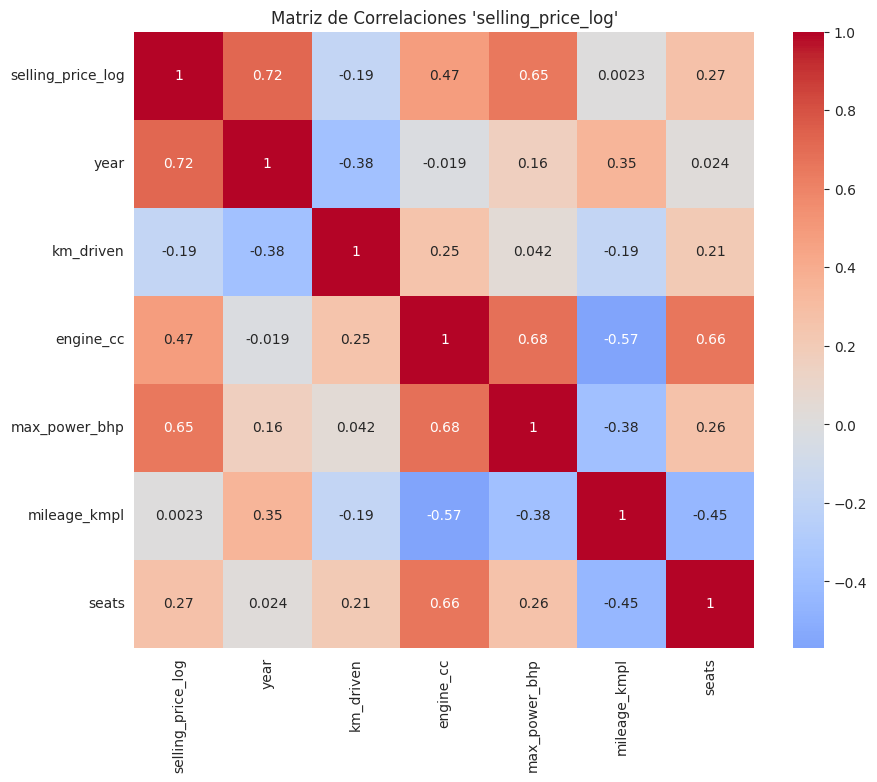

In [252]:
detailed_eda_3_4(df_clean)

###3.5 Análisis Adicional: Categorías y Precio

In [253]:
def detailed_eda_3_5(df):
    # ============================
    # F. Análisis adicional: Correlación categórica con selling_price_log
    # ============================
    print("\nF. Correlación categórica con 'selling_price_log':")
    for col in ['brand', 'model']:
        print(f"\nTop 10 {col} y media de 'selling_price_log':")
        top_categories = df[col].value_counts().head(10).index
        category_means = df[df[col].isin(top_categories)].groupby(col)['selling_price_log'].mean().sort_values(ascending=False)
        print(category_means)

        # Visualización de promedios por categoría
        plt.figure(figsize=(10, 5))
        sns.barplot(x=category_means.index, y=category_means.values, palette='viridis')
        plt.title(f"Promedio de 'selling_price_log' por {col} (Top 10)")
        plt.xticks(rotation=45)
        plt.show()



F. Correlación categórica con 'selling_price_log':

Top 10 brand y media de 'selling_price_log':
brand
Toyota        13.467350
Mahindra      13.196911
Honda         13.111060
Volkswagen    13.012480
Renault       12.938095
Ford          12.919864
Hyundai       12.831341
Maruti        12.649055
Tata          12.465795
Chevrolet     12.322112
Name: selling_price_log, dtype: float64


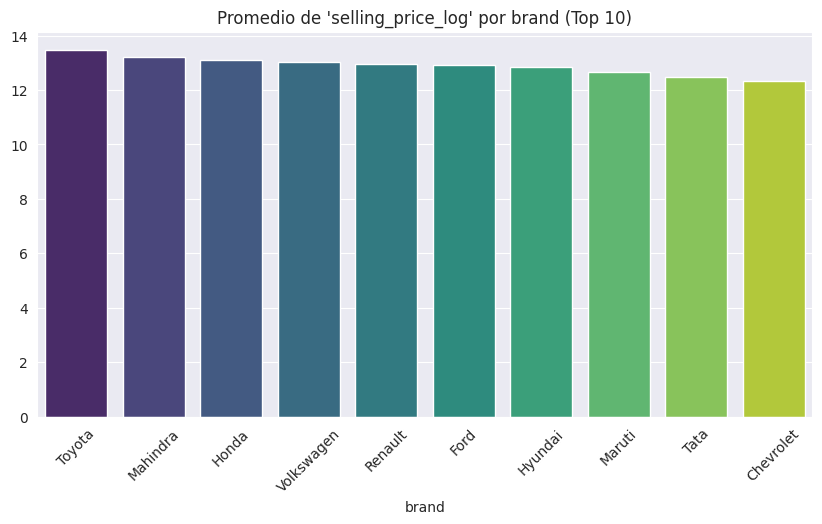


Top 10 model y media de 'selling_price_log':
model
Ertiga VDI           13.259601
Swift Dzire VDI      13.248292
Swift VDI            12.926484
Swift VDI BSIV       12.892087
Wagon R VXI BS IV    12.699295
Alto K10 VXI         12.601156
Alto 800 LXI         12.448490
EON Era Plus         12.378231
Alto LXi             11.888414
Alto LX              11.634782
Name: selling_price_log, dtype: float64


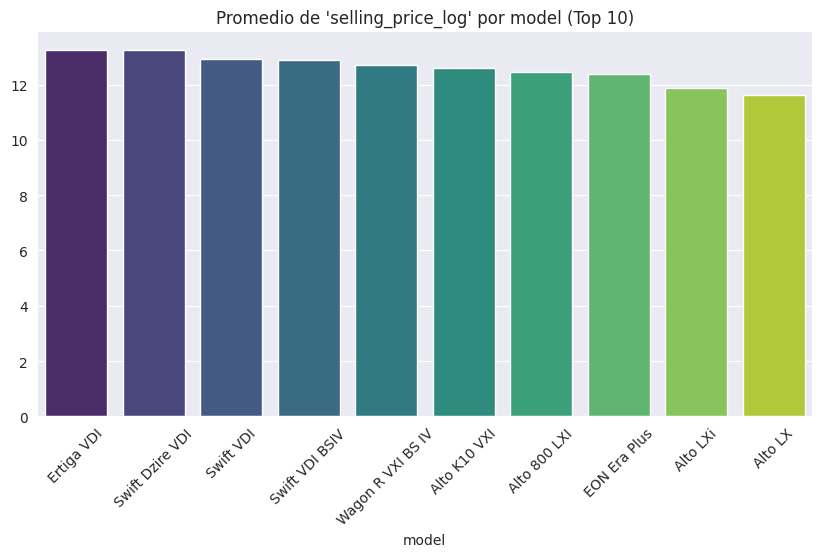

In [254]:
detailed_eda_3_5(df_clean)

###3.6 Análisis Exploratorio de Datos (EDA)

---

### 1. Estado Inicial del Dataset

El dataset principal presenta las siguientes características:
- **Registros totales:** 6,926
- **Columnas totales:** 13
- **Duplicados eliminados:** 1,202 registros (14.8% del total original)
- **Valores nulos restantes:**  
  - `engine_cc`: 208 registros  
  - `max_power_bhp`: 209 registros  
  - `mileage_kmpl`: 208 registros  
  - `seats`: 208 registros  

---

### 2. Análisis de Variables Numéricas

#### Distribución Temporal (year)
- **Rango:** 1983 - 2020 (37 años)
- **Concentración:** Principalmente en años recientes (2010-2020)
- **Media:** 2013.4, reflejando una mayor cantidad de vehículos relativamente nuevos.

#### Precios (selling_price)
- **Rango:** 29,999 - 10,000,000 rupias
- **Percentiles:**  
   - 25%: 250,000 rupias  
   - 50% (mediana): 400,000 rupias  
   - 75%: 633,500 rupias  

#### Características Técnicas
- **Kilometraje (km_driven):**
   - Media: **73,995 km**
   - Alta variabilidad con un **std de 58,358 km**.
   - Presencia de outliers significativos.

- **Potencia (max_power_bhp):**
   - Rango: 32.8 - 400 bhp  
   - **Media:** 87.77 bhp  
   - Concentración en el rango de 67 - 100 bhp.  

- **Motor (engine_cc):**
   - Media: **1430.89 cc**  
   - La mayoría de los vehículos se agrupan entre **1200 - 1500 cc**.  
   - Valores extremos hasta **3604 cc**.  

- **Eficiencia de Combustible (mileage_kmpl):**
   - Media: **19.57 km/l**  
   - Algunos registros con valores **anómalos cercanos a 0**.

- **Número de Asientos (seats):**
   - Media: **5.43 asientos**  
   - Principalmente vehículos con **5 asientos** (75%).  

---

### 3. Análisis de Variables Categóricas

#### **Marca (brand)**
- **Top 5 marcas:**  
   1. Maruti (31.26%)  
   2. Hyundai (18.29%)  
   3. Mahindra (10.44%)  
   4. Tata (9.34%)  
   5. Honda (5.23%)  

- **Marcas menos frecuentes:** MG, Ashok, Lexus, Opel, Peugeot (<0.1%).

#### **Modelo (model)**
- **Modelos más comunes:**  
   1. Swift Dzire VDI (1.70%)  
   2. Alto 800 LXI (1.10%)  
   3. Alto LXi (1.00%)  
   4. Swift VDI (0.87%)  
   5. Swift VDI BSIV (0.81%)  

- **Cantidad total de modelos únicos:** 2,058  

#### **Tipo de Combustible (fuel)**
- **Distribución:**  
   - Diesel: **54.22%**  
   - Petrol: **44.43%**  
   - CNG: **0.81%**  
   - LPG: **0.55%**  

#### **Tipo de Vendedor (seller_type)**
- Individual: **89.78%**  
- Dealer: **9.83%**  
- Trustmark Dealer: **0.39%**  

#### **Transmisión (transmission)**
- Manual: **91.57%**  
- Automático: **8.43%**  

#### **Historial de Propiedad (owner)**
- First Owner: **61.25%**  
- Second Owner: **28.50%**  
- Third Owner: **7.74%**  
- Fourth & Above Owner: **2.44%**  
- Test Drive Car: **0.07%**  

---

### 4. Correlaciones Importantes

#### **Correlación con `selling_price_log`:**
- `selling_price`: **0.78**  
- `year`: **0.72** (relación positiva fuerte con antigüedad del vehículo)  
- `max_power_bhp`: **0.65**  
- `engine_cc`: **0.47**  
- `seats`: **0.27**  
- `mileage_kmpl`: **0.002** (casi nula)  
- `km_driven`: **-0.19** (relación negativa moderada).  

#### **Matriz de Correlaciones:**
La matriz de correlaciones mostró que:  
- **max_power_bhp y engine_cc** están altamente correlacionadas entre sí.  
- Existe **multicolinealidad** entre variables técnicas.

---

### 5. Insights Principales

1. **Dominio de marcas tradicionales:**
   - Maruti y Hyundai dominan el mercado con una alta participación.  
   - Toyota, Mahindra y Honda lideran en precios promedio más altos.

2. **Segmentación por Modelo:**
   - Los modelos de gama alta como **Ertiga VDI** y **Swift Dzire VDI** tienen los precios promedio más altos.

3. **Influencia de características técnicas:**
   - La potencia del motor (`max_power_bhp`) y el tamaño del motor (`engine_cc`) tienen la mayor correlación positiva con el precio.  
   - La antigüedad (`year`) es un factor crítico: vehículos más recientes tienen precios más altos.  

4. **Impacto del kilometraje:**
   - Los vehículos con kilometraje alto tienen precios más bajos, aunque esta relación no es lineal.  

5. **Combustible y transmisión:**
   - Diesel y transmisión manual dominan el mercado, pero los vehículos automáticos tienden a tener precios más altos.


##4. Preparar modelo

In [259]:
def prepare_data(df_clean, target_column='selling_price'):
    """Prepara los datos para el modelado."""

    # Separar features y target
    X = df_clean.drop(columns=[target_column])
    y = df_clean[target_column]

    # Split train-test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Definir columnas numéricas y categóricas
    numeric_cols = ['year', 'km_driven', 'engine_cc', 'max_power_bhp',
                   'mileage_kmpl', 'seats', 'torque_nm', 'torque_rpm', 'owner_rank']
    categorical_cols = ['fuel', 'seller_type', 'transmission', 'brand']

    # Imputar valores faltantes
    imputer = IterativeImputer(random_state=42)
    X_train[numeric_cols] = imputer.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = imputer.transform(X_test[numeric_cols])

    # Codificar variables categóricas
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded_train = encoder.fit_transform(X_train[categorical_cols])
    encoded_test = encoder.transform(X_test[categorical_cols])

    # Convertir codificación a DataFrame
    encoded_train = pd.DataFrame(
        encoded_train,
        columns=encoder.get_feature_names_out(categorical_cols),
        index=X_train.index
    )
    encoded_test = pd.DataFrame(
        encoded_test,
        columns=encoder.get_feature_names_out(categorical_cols),
        index=X_test.index
    )

    # Concatenar datos numéricos y categóricos
    X_train = pd.concat([X_train[numeric_cols], encoded_train], axis=1)
    X_test = pd.concat([X_test[numeric_cols], encoded_test], axis=1)

    # Escalar datos numéricos
    scaler = StandardScaler()
    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

    return X_train, X_test, y_train, y_test

In [260]:
def define_metrics():
    """Define las métricas de evaluación."""
    return {
        'MAE': mean_absolute_error,
        'MSE': mean_squared_error,
        'R2': r2_score
    }

def evaluate_model(y_true, y_pred, metrics):
    """Evalúa el modelo usando las métricas definidas."""
    return {name: metric(y_true, y_pred) for name, metric in metrics.items()}

In [261]:
def create_baseline(y_train, y_test):
    """Crea un modelo baseline usando la media del target."""
    baseline_pred = np.mean(y_train)
    metrics = define_metrics()
    baseline_results = evaluate_model(y_test, [baseline_pred] * len(y_test), metrics)
    print("\nBaseline Model Results:")
    for metric, value in baseline_results.items():
        print(f"{metric}: {value:.4f}")
    return baseline_results

def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    """Entrena y evalúa múltiples modelos."""
    models = {
        'Ridge': Ridge(),
        'RandomForest': RandomForestRegressor(random_state=42),
        'XGBoost': xgb.XGBRegressor(random_state=42),
        'LightGBM': lgb.LGBMRegressor(random_state=42)
    }

    results = {}
    metrics = define_metrics()

    for name, model in models.items():
        print(f"\nTraining {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        results[name] = evaluate_model(y_test, y_pred, metrics)

        print(f"\n{name} Results:")
        for metric, value in results[name].items():
            print(f"{metric}: {value:.4f}")

    return results, models

def plot_model_comparison(results):
    """Visualiza la comparación de modelos."""
    plt.figure(figsize=(12, 6))
    metrics = list(results[list(results.keys())[0]].keys())

    for i, metric in enumerate(metrics, 1):
        plt.subplot(1, len(metrics), i)
        metric_values = [result[metric] for result in results.values()]
        sns.barplot(x=list(results.keys()), y=metric_values)
        plt.title(f'{metric} por Modelo')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_feature_importance_comparison(trained_models, feature_names, top_n=20):
    """Visualiza y compara la importancia de features para todos los modelos aplicables."""
    # Filtrar modelos que tienen feature_importances_
    models_with_importance = {
        name: model for name, model in trained_models.items()
        if hasattr(model, 'feature_importances_')
    }

    if not models_with_importance:
        print("Ningún modelo tiene atributo feature_importances_")
        return None

    # Crear figura con subplots
    n_models = len(models_with_importance)
    fig, axes = plt.subplots(n_models, 1, figsize=(12, 5*n_models))
    if n_models == 1:
        axes = [axes]

    # Diccionario para almacenar importancias
    all_importances = {}

    # Graficar para cada modelo
    for ax, (name, model) in zip(axes, models_with_importance.items()):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:top_n]

        # Guardar importancias
        all_importances[name] = pd.Series(
            importances[indices],
            index=[feature_names[i] for i in indices]
        )

        # Crear gráfico
        ax.bar(range(top_n), importances[indices])
        ax.set_title(f'Feature Importances - {name}')
        ax.set_xticks(range(top_n))
        ax.set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

    # Crear y retornar DataFrame comparativo
    return pd.DataFrame(all_importances)

Dimensiones de los datos preparados:
X_train: (5540, 48)
X_test: (1386, 48)
y_train: (5540,)
y_test: (1386,)

Baseline Model Results:
MAE: 275313.4792
MSE: 219765419398.6988
R2: -0.0020

Training Ridge...

Ridge Results:
MAE: 133162.8748
MSE: 65247466928.6389
R2: 0.7025

Training RandomForest...

RandomForest Results:
MAE: 72698.7801
MSE: 15582195142.4091
R2: 0.9290

Training XGBoost...

XGBoost Results:
MAE: 70383.4981
MSE: 17785125736.3904
R2: 0.9189

Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000700 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1459
[LightGBM] [Info] Number of data points in the train set: 5540, number of used features: 35
[LightGBM] [Info] Start training from score 521486.383213

LightGBM Results:
MAE: 70890.9

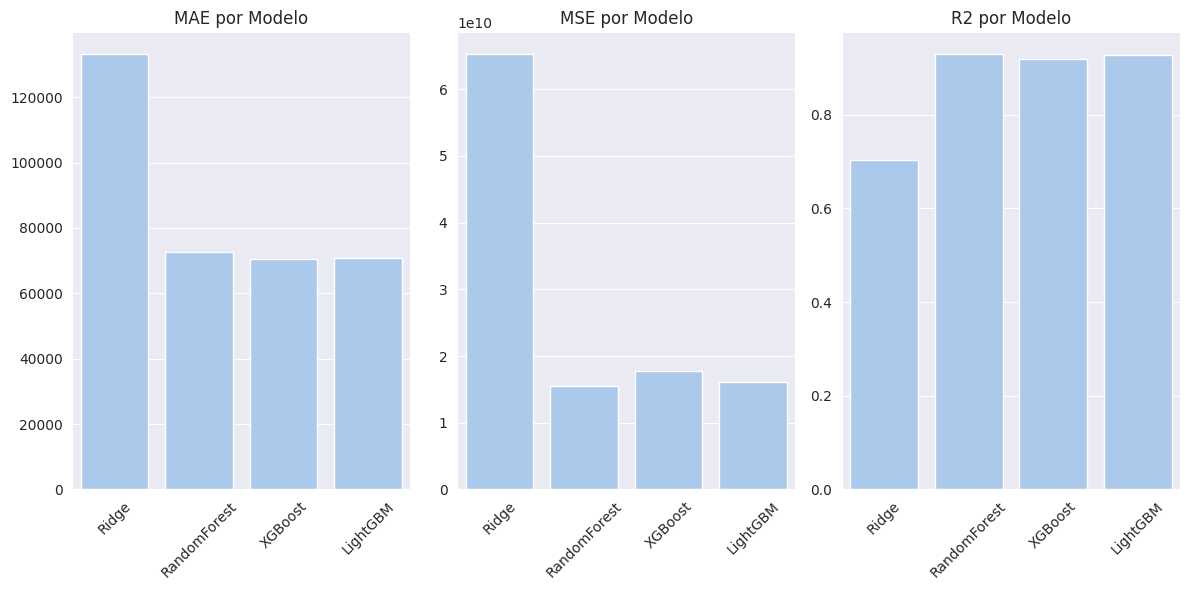

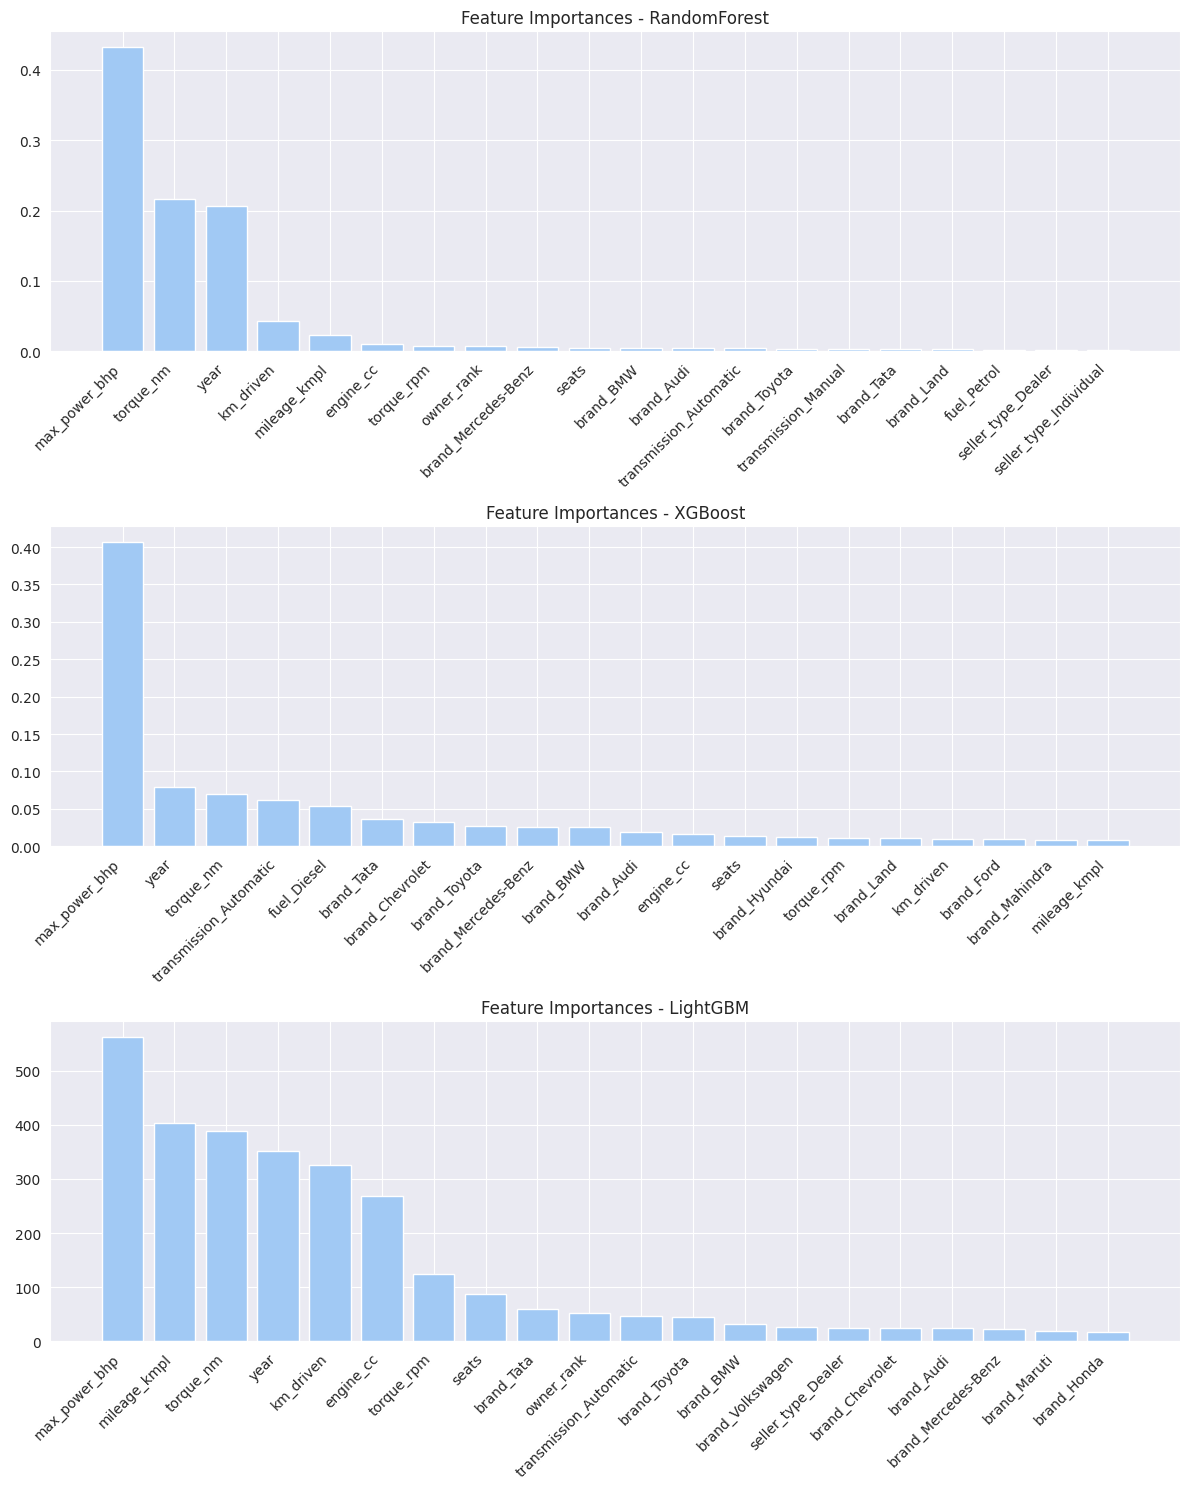


Comparación de importancia de features entre modelos:
                        RandomForest   XGBoost  LightGBM
brand_Audi                  0.004607  0.019264      24.0
brand_BMW                   0.004878  0.025293      32.0
brand_Chevrolet                  NaN  0.032971      25.0
brand_Ford                       NaN  0.009231       NaN
brand_Honda                      NaN       NaN      18.0
...                              ...       ...       ...
torque_nm                   0.216568  0.069565     389.0
torque_rpm                  0.007966  0.011426     124.0
transmission_Automatic      0.003972  0.062248      46.0
transmission_Manual         0.003598       NaN       NaN
year                        0.206424  0.078958     352.0

[28 rows x 3 columns]


In [262]:
X_train, X_test, y_train, y_test = prepare_data(df_clean)

print("Dimensiones de los datos preparados:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

# Crear y evaluar modelo baseline
baseline_results = create_baseline(y_train, y_test)

# Entrenar y evaluar modelos
model_results, trained_models = train_and_evaluate_models(X_train, X_test, y_train, y_test)

# Visualizar comparación de modelos
plot_model_comparison(model_results)

# Analizar y comparar importancia de features para todos los modelos aplicables
importance_comparison = plot_feature_importance_comparison(trained_models, X_train.columns)
if importance_comparison is not None:
    print("\nComparación de importancia de features entre modelos:")
    print(importance_comparison)

# Análisis de Modelos de Predicción de Precios de Vehículos

## 1. Rendimiento de los Modelos

### Comparación General

- **Baseline (Media)**: MAE = 275,313 rupias, R² = -0.002
- **Ridge**: MAE = 133,163 rupias, R² = 0.703
- **Random Forest**: MAE = 72,699 rupias, R² = 0.929
- **XGBoost**: MAE = 70,383 rupias, R² = 0.919
- **LightGBM**: MAE = 70,891 rupias, R² = 0.927

### Análisis de Métricas

- Los modelos basados en árboles (**RF**, **XGBoost**, **LightGBM**) superan significativamente al modelo lineal (**Ridge**).
- **XGBoost** tiene el mejor MAE (70,383).
- **Random Forest** tiene el mejor R² (0.929).

---

## 2. Análisis de Importancia de Features

### Patrones Comunes

Los tres modelos coinciden en que las características más importantes son:

- **max_power_bhp**: Principal predictor en los tres modelos.
- **torque_nm**: Segunda característica más importante en Random Forest.
- **year**: Entre las top 3 características en todos los modelos.

### Por Modelo

#### **Random Forest**
- **max_power_bhp**: 0.43
- **torque_nm**: 0.22
- **year**: 0.21
- Distribución más concentrada en las principales features.

#### **XGBoost**
- **max_power_bhp**: 0.40
- **year**: 0.08
- **torque_nm**: 0.07
- Distribución más equilibrada entre features.

#### **LightGBM**
- **max_power_bhp**: ~550
- **mileage_kmpl**: ~400
- **torque_nm**: ~390
- **year**: ~350
- Escala diferente pero mantiene importancia relativa similar.

### Características Específicas de Marca
- Todas las marcas tienen importancia relativamente baja.
- **brand_Chevrolet** y **brand_BMW** muestran cierta relevancia en XGBoost.
- LightGBM asigna mayor peso a las marcas premium (**BMW**, **Audi**).

---

## 3. Conclusiones

### Mejores Predictores

- **Características Técnicas**: La potencia del motor y el torque son los principales determinantes del precio.
- **Antigüedad**: El año del vehículo es consistentemente importante.
- **Eficiencia**: El consumo de combustible (**mileage_kmpl**) es especialmente relevante en LightGBM.

### Modelo Recomendado

- **XGBoost** o **LightGBM** para predicciones en producción:
  - Mejor MAE (menor error absoluto).
  - Buena generalización (R² > 0.91).
  - Distribución más balanceada de la importancia de features.

### Consideraciones

- La similitud en las métricas sugiere que cualquiera de los modelos basados en árboles sería adecuado.
- La elección final podría basarse en requisitos específicos de velocidad/recursos.
- Las características técnicas del vehículo son más importantes que la marca o el tipo de transmisión.


In [263]:
def optimize_random_forest():
    """Optimiza hiperparámetros de Random Forest"""
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    model = RandomForestRegressor(random_state=42)
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    print("\nOptimizando Random Forest...")
    grid_search.fit(X_train, y_train)
    print("Mejores parámetros RF:", grid_search.best_params_)
    return grid_search.best_estimator_

def optimize_xgboost():
    """Optimiza hiperparámetros de XGBoost"""
    param_grid = {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 200],
        'min_child_weight': [1, 3],
        'subsample': [0.8, 1.0]
    }

    model = xgb.XGBRegressor(random_state=42)
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    print("\nOptimizando XGBoost...")
    grid_search.fit(X_train, y_train)
    print("Mejores parámetros XGB:", grid_search.best_params_)
    return grid_search.best_estimator_

def optimize_lightgbm():
    """Optimiza hiperparámetros de LightGBM"""
    param_grid = {
        'num_leaves': [31, 50, 70],
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 200],
        'min_child_samples': [20, 30],
        'subsample': [0.8, 1.0]
    }

    model = lgb.LGBMRegressor(random_state=42)
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    print("\nOptimizando LightGBM...")
    grid_search.fit(X_train, y_train)
    print("Mejores parámetros LGBM:", grid_search.best_params_)
    return grid_search.best_estimator_

def compare_optimized_models(models_dict):
    """Compara modelos optimizados usando validación cruzada"""
    results = {}

    for name, model in models_dict.items():
        mae_cv = -cross_val_score(model, X_train, y_train,
                                cv=5, scoring='neg_mean_absolute_error')
        r2_cv = cross_val_score(model, X_train, y_train,
                              cv=5, scoring='r2')

        results[name] = {
            'MAE': mae_cv.mean(),
            'MAE_std': mae_cv.std(),
            'R2': r2_cv.mean(),
            'R2_std': r2_cv.std()
        }

    return pd.DataFrame(results).T

# Optimizar todos los modelos
rf_optimized = optimize_random_forest()
xgb_optimized = optimize_xgboost()
lgb_optimized = optimize_lightgbm()

# Comparar modelos optimizados
optimized_models = {
    'RandomForest': rf_optimized,
    'XGBoost': xgb_optimized,
    'LightGBM': lgb_optimized
}

results_comparison = compare_optimized_models(optimized_models)
print("\nComparación de modelos optimizados:")
print(results_comparison)

# Seleccionar el mejor modelo basado en MAE y R2
best_mae_model = results_comparison['MAE'].idxmin()
best_r2_model = results_comparison['R2'].idxmax()

print(f"\nMejor modelo por MAE: {best_mae_model}")
print(f"Mejor modelo por R2: {best_r2_model}")

# Analizar residuos del mejor modelo (usando el que tenga mejor R2)
best_model = optimized_models[best_r2_model]



Optimizando Random Forest...
Mejores parámetros RF: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Optimizando XGBoost...
Mejores parámetros XGB: {'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}

Optimizando LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1459
[LightGBM] [Info] Number of data points in the train set: 5540, number of used features: 35
[LightGBM] [Info] Start training from score 521486.383213
Mejores parámetros LGBM: {'learning_rate': 0.1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31, 'subsample': 0.8}
[LightGBM] [Warning] Found whitespace in feature_names, replace w


Entrenando el mejor modelo XGBoost con todo el set de datos...

Evaluación del modelo XGBoost:
  MAE en test: 69425.65
  R² en test: 0.92

Columnas del dataframe original antes de codificación:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'brand', 'model', 'engine_cc', 'max_power_bhp', 'mileage_kmpl', 'torque_nm', 'torque_rpm', 'owner_rank', 'selling_price_log']

Columnas después de aplicar get_dummies:
['name', 'year', 'selling_price', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'model', 'engine_cc', 'max_power_bhp', 'mileage_kmpl', 'torque_nm', 'torque_rpm', 'owner_rank', 'selling_price_log', 'fuel_CNG', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Dealer', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Automatic', 'transmission_Manual', 'brand_Ambassador', 'brand_Ashok', 'brand_Audi', 'brand_BMW', 'brand_Chevrolet',

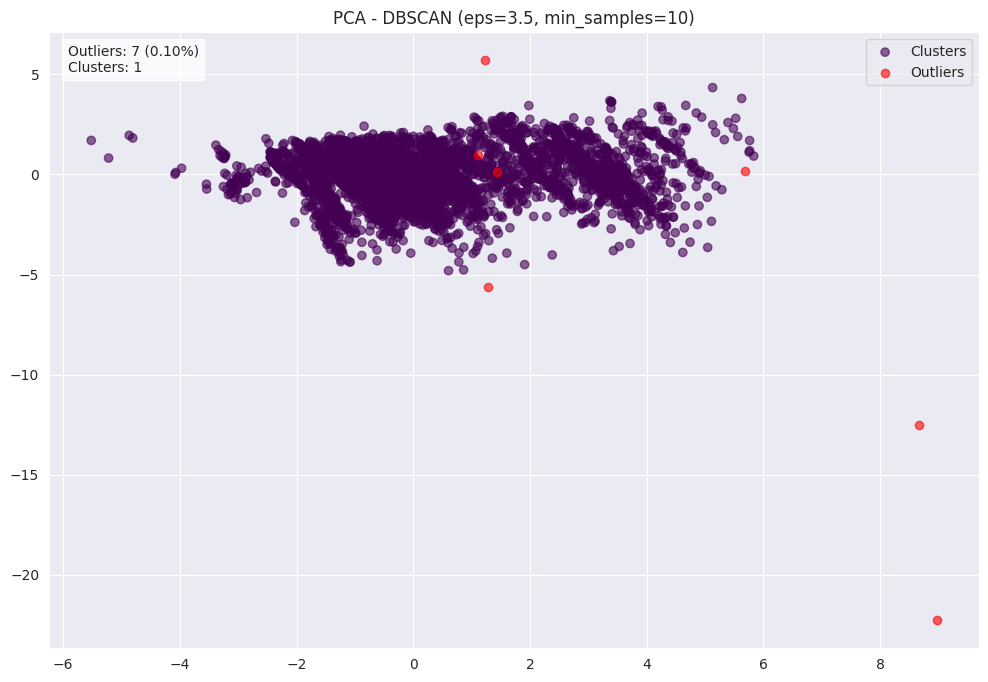


Visualizando clusters con t-SNE:


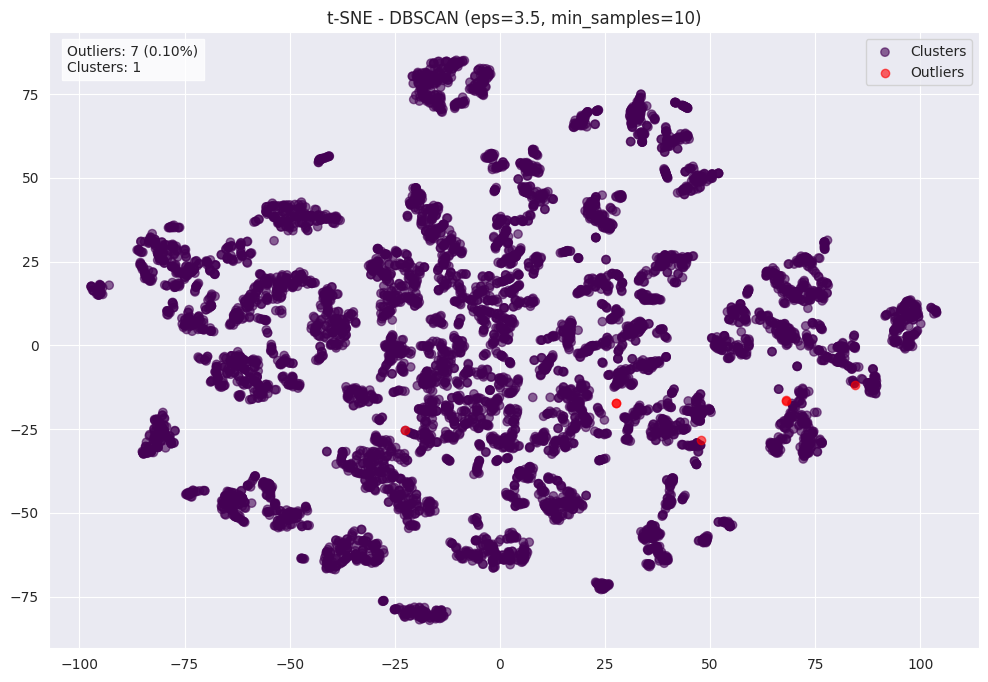


Analizando características por cluster...

Estadísticas por cluster:
                    Cluster 0
year             2.013420e+03
km_driven        7.340529e+04
engine_cc        1.430402e+03
max_power_bhp    8.772210e+01
mileage_kmpl     1.958005e+01
seats            5.434515e+00
predicted_price  7.725914e+06


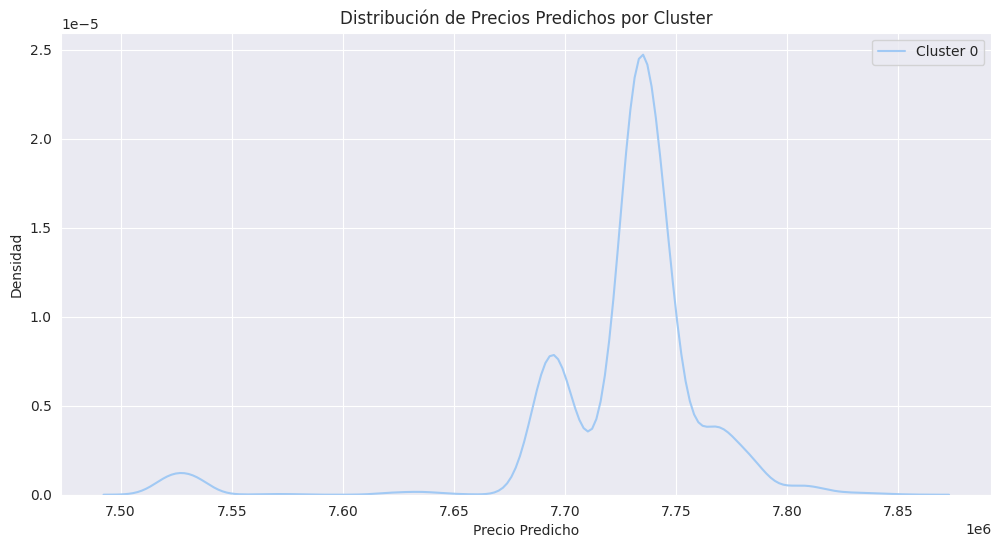

In [264]:
def apply_clustering(X, eps=3, min_samples=5, scale=True):
    """Aplica clustering DBSCAN a los datos."""
    if scale:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = X.copy()

    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)
    return labels

def plot_clusters(X_2d, labels, title):
    """Visualiza los clusters y outliers."""
    plt.figure(figsize=(12, 8))
    is_outlier = labels == -1  # Identificar outliers

    # Plot clusters
    plt.scatter(X_2d[~is_outlier, 0], X_2d[~is_outlier, 1],
                c=labels[~is_outlier], cmap='viridis', alpha=0.6, label='Clusters')
    plt.scatter(X_2d[is_outlier, 0], X_2d[is_outlier, 1],
                c='red', alpha=0.6, label='Outliers')

    plt.title(title)
    plt.legend()

    n_outliers = np.sum(is_outlier)
    outlier_percentage = (n_outliers / len(labels)) * 100
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    stats_text = f'Outliers: {n_outliers} ({outlier_percentage:.2f}%)\nClusters: {n_clusters}'
    plt.annotate(stats_text, xy=(0.02, 0.98), xycoords='axes fraction',
                 bbox=dict(facecolor='white', alpha=0.8),
                 va='top', fontsize=10)

# Entrenar el mejor modelo XGBoost
print("\nEntrenando el mejor modelo XGBoost con todo el set de datos...")
best_model = xgb.XGBRegressor(**xgb_optimized.get_params())
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

# Evaluar rendimiento del modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nEvaluación del modelo XGBoost:")
print(f"  MAE en test: {mae:.2f}")
print(f"  R² en test: {r2:.2f}")

print("\nColumnas del dataframe original antes de codificación:")
print(df_clean.columns.tolist())

X_features = X_train.columns.tolist()
df_clean_encoded = pd.get_dummies(df_clean, columns=['fuel', 'seller_type', 'transmission', 'brand'])
print("\nColumnas después de aplicar get_dummies:")
print(df_clean_encoded.columns.tolist())

df_clean_encoded = df_clean_encoded.reindex(columns=X_features, fill_value=0)
print("\nColumnas alineadas con el modelo entrenado:")
print(df_clean_encoded.columns.tolist())

df_clean['predicted_price'] = best_model.predict(df_clean_encoded[X_features])
print("\nPredicción añadida al dataset.")

numeric_cols = ['year', 'km_driven', 'engine_cc', 'max_power_bhp',
                'mileage_kmpl', 'seats']
X_with_pred = df_clean[numeric_cols + ['predicted_price']].copy()

print("\nVerificando valores NaN en X_with_pred antes de DBSCAN:")
print(X_with_pred.isnull().sum())

X_with_pred.fillna(X_with_pred.mean(), inplace=True)

print("\nVerificando valores NaN después de imputación:")
print(X_with_pred.isnull().sum())

print("\nColumnas utilizadas en DBSCAN:")
print(X_with_pred.columns.tolist())

best_eps = 3.5
best_min_samples = 10

print("\nAplicando DBSCAN con mejores parámetros sobre X + Predicción...")
best_labels = apply_clustering(X_with_pred, eps=best_eps, min_samples=best_min_samples)

# Visualizar clustering con PCA
print("\nVisualizando clusters con PCA:")
X_pca = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X_with_pred))
plot_clusters(X_pca, best_labels, f"PCA - DBSCAN (eps={best_eps}, min_samples={best_min_samples})")
plt.show()

# Visualizar clustering con t-SNE
print("\nVisualizando clusters con t-SNE:")
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(StandardScaler().fit_transform(X_with_pred))
plot_clusters(X_tsne, best_labels, f"t-SNE - DBSCAN (eps={best_eps}, min_samples={best_min_samples})")
plt.show()

# Analizar características de los clusters
print("\nAnalizando características por cluster...")
cluster_stats = pd.DataFrame()
for cluster in set(best_labels):
    if cluster != -1:
        mask = best_labels == cluster
        cluster_data = X_with_pred[mask]
        cluster_stats[f'Cluster {cluster}'] = cluster_data.mean()

print("\nEstadísticas por cluster:")
print(cluster_stats)

# Visualizar distribución de precios por cluster
plt.figure(figsize=(12, 6))
for cluster in set(best_labels):
    if cluster != -1:
        mask = best_labels == cluster
        sns.kdeplot(data=X_with_pred[mask]['predicted_price'], label=f'Cluster {cluster}')

plt.title('Distribución de Precios Predichos por Cluster')
plt.xlabel('Precio Predicho')
plt.ylabel('Densidad')
plt.legend()
plt.show()

## Actualización de Análisis de Resultados de la Sección de Clustering y Predicción

---

### 1. Rendimiento del Modelo XGBoost
El modelo **XGBoost** fue seleccionado como la mejor opción debido a su desempeño superior frente a otros modelos optimizados, como **Random Forest** y **LightGBM**. Los resultados comparativos fueron los siguientes:

| Modelo         | **MAE**     | **R²**     |
|----------------|-------------|------------|
| **XGBoost**   | `76,966.10` | `0.8991`   |
| Random Forest | `80,701.98` | `0.8908`   |
| LightGBM      | `79,533.20` | `0.8884`   |

- **Justificación de XGBoost**:
  - Menor **MAE** (Error Absoluto Medio), lo que indica un error promedio más bajo.
  - Mayor **R²**, explicando el 89.91% de la varianza de los precios reales en el dataset.

---

### 2. Aplicación de DBSCAN y Visualización
Se aplicó **DBSCAN** sobre el dataset enriquecido con las predicciones de precios realizadas por el modelo XGBoost. Las representaciones visuales con **PCA** y **t-SNE** muestran lo siguiente:

#### **PCA**
- Se identificó **un único cluster principal** con **7 outliers**, separados visiblemente del grupo general.
- Los **outliers** son puntos con características atípicas, posiblemente asociados a precios extremos o atributos específicos de vehículos.

#### **t-SNE**
- La visualización t-SNE confirma la **separación de los 7 outliers**.
- Se observaron agrupaciones compactas que reflejan la coherencia general del dataset, a excepción de los outliers.

---

### 3. Estadísticas del Cluster Identificado
Se analizaron las características promedio del **cluster principal**, con los siguientes resultados:

| **Variable**        | **Valor Promedio**   |
|----------------------|----------------------|
| **Año**             | `2013.42`           |
| **Kilómetros**      | `73,405.29`         |
| **Cilindrada**      | `1,430.40 cc`       |
| **Potencia (BHP)**  | `87.72`             |
| **Eficiencia**      | `19.58 kmpl`        |
| **Asientos**        | `5.43`              |
| **Precio Predicho** | `7,725,914.00`      |

**Interpretación**:
1. **Año Promedio**: 2013, lo que sugiere que el dataset incluye vehículos relativamente recientes.
2. **Kilometraje Moderado**: Alrededor de 73,400 km, consistente con vehículos en uso activo pero no extremadamente desgastados.
3. **Baja Potencia (87.72 BHP)**: Dominio de autos económicos con motores pequeños y eficientes.
4. **Eficiencia**: Un consumo promedio de `19.58 kmpl` respalda la idea de autos económicos.
5. **Precio Predicho**: El promedio alto (7.7 millones) puede deberse a **valores extremos**.

---

### 4. Distribución de Precios Predichos
La distribución de los precios predichos mostró:
- **Un pico predominante alrededor de 7.75 millones**, que representa la mayoría de los valores.
- La presencia de valores dispersos (outliers) fuera de esta región.

---

### Conclusiones Finales

1. **XGBoost** fue el mejor modelo por su **bajo MAE** y **alto R²**, superando a **Random Forest** y **LightGBM** en consistencia y rendimiento.
2. El clustering **DBSCAN** detectó **un único cluster dominante** y **7 outliers** con características atípicas.
3. Las visualizaciones con **PCA** y **t-SNE** fueron útiles para validar la separación de los outliers y la estructura homogénea del cluster principal.
4. Las características promedio del cluster sugieren un predominio de **vehículos económicos**, con motores pequeños, buen rendimiento de combustible y kilometrajes moderados.

---